Sarsa and Q-learning

Gymnasium

Gymnasium is an open-source library of standardised reinforcement-learning environments, a successor to OpenAI Gym. More information can be found here https://gymnasium.farama.org/introduction/basic_usage/

# Description

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
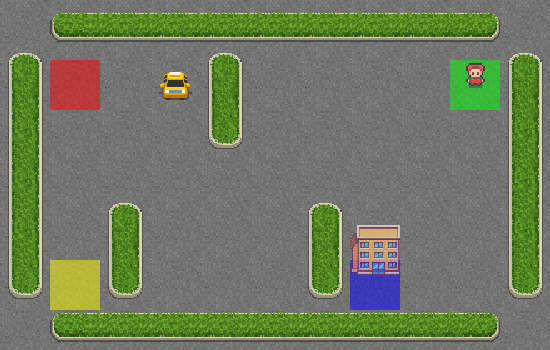

In [ ]:
import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import numpy as np
import random as rng
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm


env = gym.make(
    "Taxi-v3",
    render_mode="rgb_array"
)
env.reset()
# render the environment
env.render()


In [ ]:
# observation space - states (16 of them for each cell on the grid)
env.observation_space

Discrete(500)

In [ ]:
 # actions: left -0, down - 1, right - 2, up- 3
env.action_space

Discrete(6)

(27, -1, False, False, {'prob': 1.0, 'action_mask': array([1, 0, 0, 1, 0, 0], dtype=int8)})


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
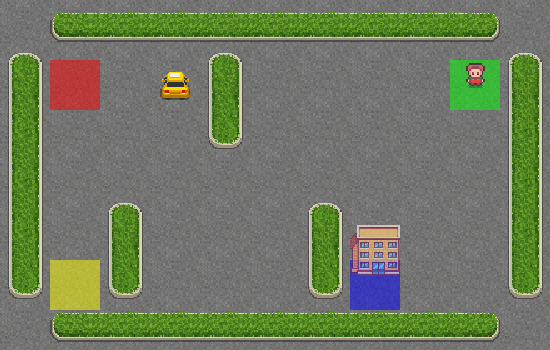

In [ ]:
#generate random action
randomAction= env.action_space.sample()
returnValue = env.step(randomAction)
# format of returnValue is (observation,reward, terminated, truncated, info)
# observation (object)  - observed state
# reward (float)        - reward that is the result of taking the action
# terminated (bool)     - is it a terminal state
# truncated (bool)      - See episode end section in description
# info (dictionary)     - in our case transition probability
print(returnValue)

env.render()
#repatedly running the cell will run a random action

Initial state of the system
Iteration: 1 and action 4
Iteration: 2 and action 5
Iteration: 3 and action 1
Iteration: 4 and action 1
Iteration: 5 and action 2
Iteration: 6 and action 0
Iteration: 7 and action 4
Iteration: 8 and action 4
Iteration: 9 and action 3
Iteration: 10 and action 2
Iteration: 11 and action 1
Iteration: 12 and action 1
Iteration: 13 and action 5
Iteration: 14 and action 5
Iteration: 15 and action 5
Iteration: 16 and action 3
Iteration: 17 and action 3
Iteration: 18 and action 4
Iteration: 19 and action 3
Iteration: 20 and action 5


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
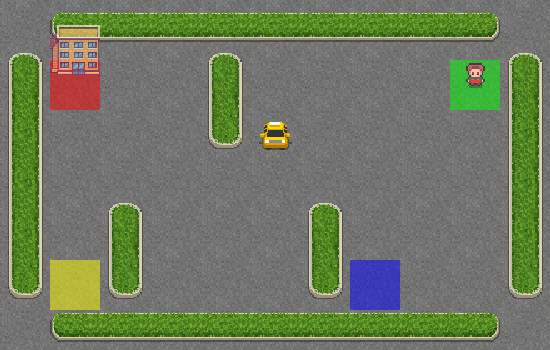

In [ ]:
#reset to initial state
env.reset()
print('Initial state of the system')

#let's try 20 random mobes
numberOfIterations=20

for i in range(numberOfIterations):
    randomAction= env.action_space.sample()
    returnValue=env.step(randomAction)
    print('Iteration: {} and action {}'.format(i+1,randomAction))
    if returnValue[2]: #if terminal state reached
        break

env.close()
env.render()

# Exploration Strategy

In [ ]:
# -------------------- PARAMETERS --------------------
from typing import NamedTuple

class Params(NamedTuple):
    total_episodes: int
    learning_rate: float
    gamma: float
    epsilon: float
    seed: int
    n_runs: int
    action_size: int
    state_size: int
# -------------------- EXPLORATION STRATEGY --------------------
class EpsilonGreedy:
    def __init__(self, epsilon):
        self.epsilon = epsilon

    def choose_action(self, action_space, state, qtable):
        if rng.uniform(0, 1) < self.epsilon:
            return action_space.sample()
        max_ids = np.where(qtable[state, :] == max(qtable[state, :]))[0]
        return rng.choice(max_ids)

# DP

In [ ]:
import numpy as np

class DynamicProgramming:
    def __init__(self, env, gamma=0.95, theta=1e-10):
        self.env = env  # must be unwrapped
        self.gamma = gamma
        self.theta = theta
        self.state_size = env.observation_space.n
        self.action_size = env.action_space.n
        self.value_table = np.zeros(self.state_size)

    def run_value_iteration(self):
        iteration = 0
        while True:
            delta = 0
            for state in range(self.state_size):
                action_values = np.zeros(self.action_size)
                for action in range(self.action_size):
                    for prob, next_state, reward, done in self.env.P[state][action]:
                        action_values[action] += prob * (reward + self.gamma * self.value_table[next_state])
                best_action_value = np.max(action_values)
                delta = max(delta, abs(self.value_table[state] - best_action_value))
                self.value_table[state] = best_action_value
            iteration += 1
            if delta < self.theta:
                break

        # Extract optimal policy
        policy = np.zeros(self.state_size, dtype=int)
        for state in range(self.state_size):
            action_values = np.zeros(self.action_size)
            for action in range(self.action_size):
                for prob, next_state, reward, done in self.env.P[state][action]:
                    action_values[action] += prob * (reward + self.gamma * self.value_table[next_state])
            policy[state] = np.argmax(action_values)

        print(f"Value Iteration converged in {iteration} iterations.")
        return policy, self.value_table


In [ ]:
# Unwrap the environment to access transition model P
base_env = env.unwrapped

# Run DP
dp_solver = DynamicProgramming(base_env, gamma=params.gamma)
dp_policy, dp_value = dp_solver.run_value_iteration()

Value Iteration converged in 259 iterations.


# Q-Learning

In [ ]:
# This Q-learning implementation is adapted from:
#Author: Andrea Pierré
# License: MIT License

class Qlearning:
    def __init__(self, learning_rate, gamma, state_size, action_size):
        self.state_size = state_size #16 in a 4x4 map
        self.action_size = action_size #actions: left -0, down - 1, right - 2, up- 3
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.reset_qtable()

    def update(self, state, action, reward, new_state):
        """Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]"""
        delta = (
            reward
            + self.gamma * np.max(self.qtable[new_state, :])
            - self.qtable[state, action]
        )
        q_update = self.qtable[state, action] + self.learning_rate * delta
        return q_update

    def reset_qtable(self):
        """Reset the Q-table."""
        self.qtable = np.zeros((self.state_size, self.action_size))

#Let's organize the Parameters that we will use

from typing import NamedTuple

class Params(NamedTuple):
    total_episodes: int  # Total episodes
    learning_rate: float  # Learning rate
    gamma: float  # Discounting rate
    epsilon: float  # Exploration probability
    seed: int  # Define a seed so that we get reproducible results
    n_runs: int  # Number of runs
    action_size: int  # Number of possible actions
    state_size: int  # Number of possible states


params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    epsilon=0.1,
    seed=123,
    n_runs=20,
    action_size=env.action_space.n,
    state_size=env.observation_space.n
)
params

# Set the seed
rng = np.random.default_rng(params.seed)

In [ ]:
def run_env_qlearn():
    rewards = np.zeros((params.total_episodes, params.n_runs))
    steps = np.zeros((params.total_episodes, params.n_runs))
    episodes = np.arange(params.total_episodes)
    qtables = np.zeros((params.n_runs, params.state_size, params.action_size))

    for run in range(params.n_runs):
        qlearner.reset_qtable()

        for episode in tqdm(episodes, desc=f"Run {run}/{params.n_runs} - Episodes", leave=False):
            state = env.reset(seed=params.seed)[0]
            step = 0
            done = False
            total_rewards = 0

            while not done:
                action = explorer.choose_action(env.action_space, state, qlearner.qtable)
                new_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                qlearner.qtable[state, action] = qlearner.update(state, action, reward, new_state)

                total_rewards += reward
                step += 1
                state = new_state

            rewards[episode, run] = total_rewards
            steps[episode, run] = step
        qtables[run, :, :] = qlearner.qtable

    return rewards, steps, episodes, qtables

In [ ]:
def plot_rewards(episodes, rewards):
    avg_rewards = rewards.mean(axis=1)
    plt.figure(figsize=(12, 6))
    plt.plot(episodes, avg_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.title("Average Reward per Episode")
    plt.grid()
    plt.ylim(-500, 20)
    plt.show()

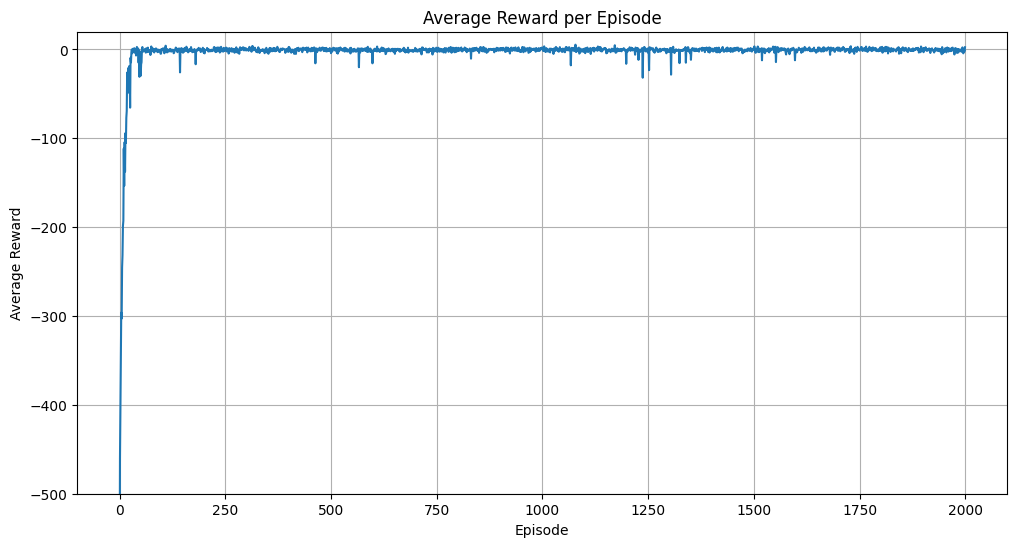

In [ ]:
qlearner = Qlearning(params.learning_rate, params.gamma, params.state_size, params.action_size)
explorer = EpsilonGreedy(params.epsilon)

rewards, steps, episodes, qtables = run_env_qlearn()
qtable = qtables.mean(axis=0)

plot_rewards(episodes, rewards)


In [ ]:
q_policy = np.argmax(qtable, axis=1)

# SARSA

In [ ]:
# SARSA agent class
class Sarsa:
    def __init__(self, learning_rate, gamma, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.reset_qtable()

    def update(self, state, action, reward, new_state, new_action):
        """SARSA Update: Q(s,a) ← Q(s,a) + α [r + γ Q(s',a') − Q(s,a)]"""
        target = reward + self.gamma * self.qtable[new_state, new_action]
        delta = target - self.qtable[state, action]
        self.qtable[state, action] += self.learning_rate * delta
        return self.qtable[state, action]

    def reset_qtable(self):
        self.qtable = np.zeros((self.state_size, self.action_size))


from typing import NamedTuple

class Params(NamedTuple):
    total_episodes: int  # Total episodes
    learning_rate: float  # Learning rate
    gamma: float  # Discounting rate
    epsilon: float  # Exploration probability
    seed: int  # Define a seed so that we get reproducible results
    n_runs: int  # Number of runs
    action_size: int  # Number of possible actions
    state_size: int  # Number of possible states


params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    epsilon=0.1,
    seed=123,
    n_runs=20,
    action_size=env.action_space.n,
    state_size=env.observation_space.n
)
params

# Set the seed
rng = np.random.default_rng(params.seed)

In [ ]:
def run_env_sarsa():
    rewards = np.zeros((params.total_episodes, params.n_runs))
    steps = np.zeros((params.total_episodes, params.n_runs))
    episodes = np.arange(params.total_episodes)
    qtables = np.zeros((params.n_runs, params.state_size, params.action_size))

    for run in range(params.n_runs):
        slearner.reset_qtable()

        for episode in tqdm(episodes, desc=f"Run {run+1}/{params.n_runs}", leave=False):
            state = env.reset(seed=params.seed)[0]
            action = explorer.choose_action(env.action_space, state, slearner.qtable)
            total_reward = 0
            step = 0
            done = False

            while not done:
                new_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                new_action = explorer.choose_action(env.action_space, new_state, slearner.qtable)

                slearner.update(state, action, reward, new_state, new_action)

                state = new_state
                action = new_action
                total_reward += reward
                step += 1

            rewards[episode, run] = total_reward
            steps[episode, run] = step
        qtables[run] = slearner.qtable

    return rewards, steps, episodes, qtables

In [ ]:
def plot_rewards_sarsa(episodes, rewards):
    avg_rewards = rewards.mean(axis=1)
    plt.figure(figsize=(12, 6))
    plt.plot(episodes, avg_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Average Reward")
    plt.title("Average Reward per Episode")
    plt.grid()
    plt.ylim(-500, 20)
    plt.show()

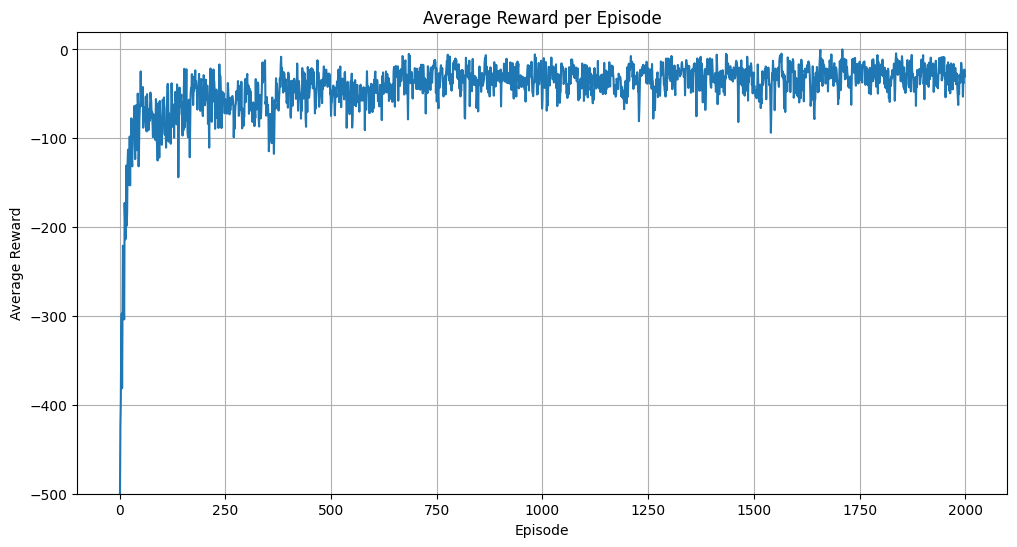

In [ ]:
slearner = Sarsa(params.learning_rate, params.gamma, params.state_size, params.action_size)
explorer = EpsilonGreedy(params.epsilon)
rewards, steps, episodes, qtables = run_env_sarsa()
s_qtable = qtables.mean(axis=0)
plot_rewards_sarsa(episodes, rewards)


In [ ]:
sarsa_policy = np.argmax(s_qtable, axis=1)

# Comparison of the Three Algorithms

In [ ]:
def policy_agreement(p1, p2):
    return np.mean(p1 == p2)

print("Q-learning vs DP:", policy_agreement(q_policy, dp_policy))
print("SARSA vs DP:", policy_agreement(sarsa_policy, dp_policy))
print("Q-learning vs SARSA:", policy_agreement(q_policy, sarsa_policy))

Q-learning vs DP: 0.364
SARSA vs DP: 0.396
Q-learning vs SARSA: 0.896


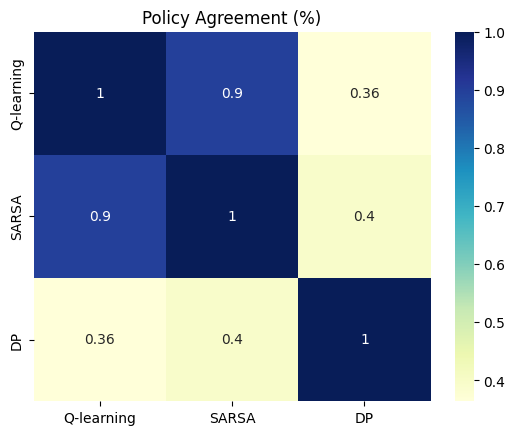

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Q-learning": q_policy,
    "SARSA": sarsa_policy,
    "DP": dp_policy
}
df = pd.DataFrame(data)
agreement_matrix = df.corr(method=lambda x, y: np.mean(x == y))

sns.heatmap(agreement_matrix, annot=True, cmap="YlGnBu")
plt.title("Policy Agreement (%)")
plt.show()